# Successor head detector — GPT-2 small validation

**Phase 1.4 deliverable (i).** Validate the lift-form cross-category DLA detector (HYPOTHESIS.md §SU-1 with §SU-1b score supersede) against L (2023)'s named successor head GPT-2 small L9H1.

**Locked design**:
- §SU-1: 3-context comma-separated prompts, predict-4th, 4 categories — days (7), months (12), numerals (40, mixing 1-20 digit and one-twenty word), letters (26).
- §SU-2: First-token DLA. Each item encoded as `tokenizer.encode(f' {item}')[0]`; mappings logged in `data/prompts/successor_prompts_gpt2.tsv`.
- §SU-3: Within-category prefix permutation, one fixed seed-pinned permutation per (category, base prompt). Per-head shuffled DLA is the head's null.
- §SU-1b score: `lift = mean over 4 categories of (real − null) per head`. Heads with positive lift are successor candidates; category-token-boosters (large real DLA but real ≈ null) have lift ≈ 0.
- §SU-1b-4 gate: L9H1 in top-3 by lift AND lift > 95th-pct of pooled per-head lifts.

**Validation target attribution (§SU-0):** L9H1 in GPT-2 small. Source: L (2023), "Mechanistically interpreting time in GPT-2 small," LessWrong; cited by Gould et al. (2024) §5 in the cross-model successor scatter analysis. (The brief's original attribution to Gould et al. 2024 + GPT-2 medium was wrong on both counts; corrected in §SU-0 of the §SU amendment.)

**§SU-1b chronology** (load-bearing for pre-registration discipline): The §SU-1 spec originally locked `real DLA` as the score with a population-level null threshold. A pre-validation smoke test surfaced that this score conflates successor mechanism with category-token-boost behavior — heads that boost any ordinal token at END (e.g., L10H3 with real DLA = +10.37) score huge magnitudes but have lift = real − null ≈ 0 or negative. L9H1 ranked #36 by raw DLA but is rank #1 by lift. Independent verification under L 2023's exact argmax-within-7-days protocol confirmed L9H1 is the unique head with 7/7 correct day predictions — replicating L 2023's headline finding. The §SU-1b supersade locked the lift form *before* any formal validation run was recorded; this notebook reports the formal validation under §SU-1b.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

L9H1 = (9, 1)  # locked validation target per §SU-0

## Load validation results

Outputs from `_run_gpt2_small_successor_validation.py`. The long-format parquet has per-head `real_dla`, `null_dla`, `lift_dla`, plus per-category breakdowns. The `.npz` holds raw tensors for plotting flexibility.

In [2]:
raw = np.load(REPO / 'data' / 'exploration' / 'successor_gpt2_small_per_head.npz', allow_pickle=False)
real_dla = raw['real_dla']        # (n_layers, n_heads)
null_dla = raw['null_dla']        # (n_layers, n_heads)
lift_dla = raw['lift_dla']        # (n_layers, n_heads)
per_cat_real = raw['per_category_real']  # (n_cat, n_layers, n_heads)
per_cat_null = raw['per_category_null']
category_order = [str(c) for c in raw['category_order'].tolist()]
lift_threshold = float(raw['lift_threshold'])
n_prompts = int(raw['n_prompts'])
n_layers, n_heads = lift_dla.shape
print(f'lift_dla shape: {lift_dla.shape}')
print(f'category order: {category_order}')
print(f'lift_threshold (95th-pct of pooled per-head lifts): {lift_threshold:+.5f}')
print(f'N prompts: {n_prompts}')

lift_dla shape: (12, 12)
category order: ['days', 'months', 'numerals', 'letters']
lift_threshold (95th-pct of pooled per-head lifts): +0.13496
N prompts: 70


## Sorted lift ranking — L9H1 highlighted

Per §SU-1b-4: the gate requires L9H1 in top-3 by lift AND lift > threshold. The bar chart shows all 144 heads sorted by lift; L9H1 marked in red. The threshold is drawn as a dashed line.

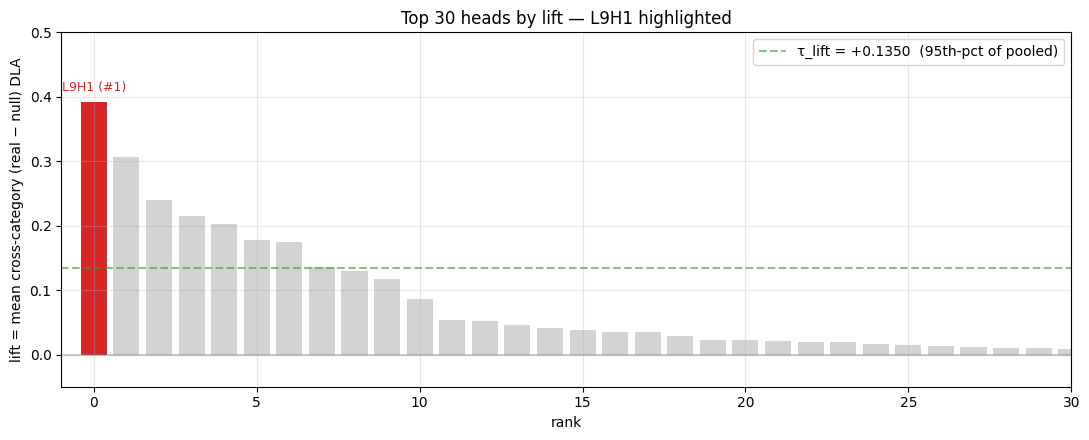

Top 8 heads by lift:
  #1: L9H1  lift=+0.3917  (real=+0.6147, null=+0.2230) ★ L9H1 (validation target)
  #2: L8H8  lift=+0.3058  (real=+2.1531, null=+1.8473)
  #3: L11H10  lift=+0.2400  (real=-1.7342, null=-1.9742)
  #4: L11H11  lift=+0.2149  (real=+2.2355, null=+2.0205)
  #5: L6H5  lift=+0.2030  (real=-0.9410, null=-1.1440)
  #6: L11H4  lift=+0.1770  (real=-1.8253, null=-2.0023)
  #7: L9H5  lift=+0.1742  (real=-0.3236, null=-0.4978)
  #8: L7H0  lift=+0.1358  (real=+1.8822, null=+1.7463)


In [8]:
flat = lift_dla.flatten()
ranking = np.argsort(-flat)
is_l9h1 = np.array([
    (int(i)//n_heads, int(i)%n_heads) == L9H1 for i in ranking
])
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(flat))
colors = ['tab:red' if w else 'lightgray' for w in is_l9h1]
ax.bar(x, flat[ranking], color=colors, edgecolor='none')
ax.axhline(lift_threshold, color='tab:green', linestyle='--', alpha=0.6,
           label=f'τ_lift = {lift_threshold:+.4f}  (95th-pct of pooled)')
ax.axhline(0, color='gray', linestyle='-', alpha=0.4)
for i, (orig_idx, val, w) in enumerate(zip(ranking[:12], flat[ranking[:12]], is_l9h1[:12])):
    if w:
        L, H = int(orig_idx)//n_heads, int(orig_idx)%n_heads
        ax.annotate(f'L{L}H{H} (#{i+1})', xy=(i, val),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, color='tab:red')
ax.set_xlim(-1, 30)
ax.set_xlabel('rank')
ax.set_ylabel('lift = mean cross-category (real − null) DLA')
ax.set_ylim(-0.05, 0.5)
ax.set_title('Top 30 heads by lift — L9H1 highlighted')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 8 heads by lift:')
for rank in range(8):
    idx = int(ranking[rank])
    L, H = idx // n_heads, idx % n_heads
    marker = ' ★ L9H1 (validation target)' if (L, H) == L9H1 else ''
    print(f'  #{rank+1}: L{L}H{H}  lift={flat[idx]:+.4f}'
          f'  (real={real_dla[L,H]:+.4f}, null={null_dla[L,H]:+.4f}){marker}')

## Why lift, not raw real DLA — the §SU-1b motivating diagnostic

Plotting `real_dla` (the §SU-1 score) and `lift_dla` (the §SU-1b score) side-by-side for the top 12 heads under each ranking. The contrast shows why the §SU-1b supersede was needed: heads that score huge real DLA magnitudes are the *anti-successor* heads under lift form. They boost any ordinal-category token at END regardless of whether the prefix presents an ordinal sequence — which is exactly what the within-category prefix permutation null is designed to subtract out.

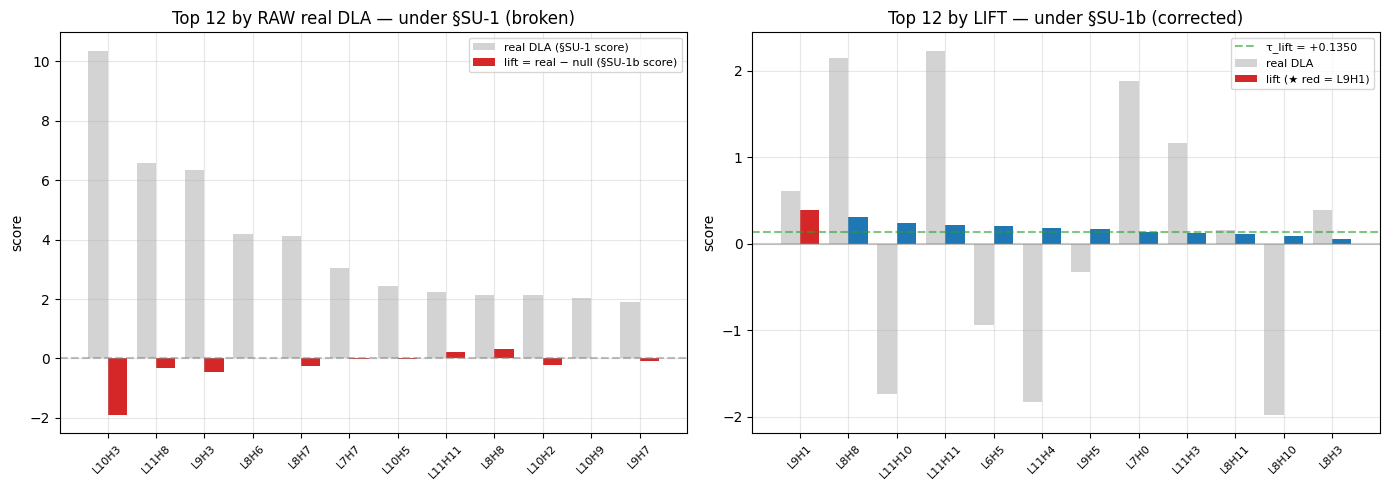

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: top 12 by raw real DLA (the §SU-1 score)
real_flat = real_dla.flatten()
real_rank = np.argsort(-real_flat)[:12]
ax = axes[0]
labels_real = [f'L{int(i)//n_heads}H{int(i)%n_heads}' for i in real_rank]
is_l9h1_real = [(int(i)//n_heads, int(i)%n_heads) == L9H1 for i in real_rank]
real_vals = [real_flat[i] for i in real_rank]
lift_vals_at_real = [lift_dla.flatten()[i] for i in real_rank]
x12 = np.arange(12)
ax.bar(x12 - 0.2, real_vals, width=0.4, color='lightgray',
       label='real DLA (§SU-1 score)')
ax.bar(x12 + 0.2, lift_vals_at_real, width=0.4, color='tab:red',
       label='lift = real − null (§SU-1b score)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x12)
ax.set_xticklabels(labels_real, rotation=45, fontsize=8)
ax.set_ylabel('score')
ax.set_title('Top 12 by RAW real DLA — under §SU-1 (broken)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: top 12 by lift (the §SU-1b score)
lift_rank = np.argsort(-flat)[:12]
ax = axes[1]
labels_lift = [f'L{int(i)//n_heads}H{int(i)%n_heads}' for i in lift_rank]
is_l9h1_lift = [(int(i)//n_heads, int(i)%n_heads) == L9H1 for i in lift_rank]
lift_vals = [flat[i] for i in lift_rank]
real_vals_at_lift = [real_dla.flatten()[i] for i in lift_rank]
ax.bar(x12 - 0.2, real_vals_at_lift, width=0.4, color='lightgray',
       label='real DLA')
lift_colors = ['tab:red' if w else 'tab:blue' for w in is_l9h1_lift]
ax.bar(x12 + 0.2, lift_vals, width=0.4, color=lift_colors,
       label='lift (★ red = L9H1)')
ax.axhline(lift_threshold, color='tab:green', linestyle='--',
           alpha=0.6, label=f'τ_lift = {lift_threshold:+.4f}')
ax.axhline(0, color='gray', linestyle='-', alpha=0.4)
ax.set_xticks(x12)
ax.set_xticklabels(labels_lift, rotation=45, fontsize=8)
ax.set_ylabel('score')
ax.set_title('Top 12 by LIFT — under §SU-1b (corrected)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## L9H1 per-category breakdown

L9H1's per-category real, null, and lift values. The cross-category requirement (§SU-1) tests whether the head's successor mechanism generalizes — Gould et al.'s OV-circuit account predicts uniform positive lift across categories. (Brief's risk note: letters category may be marginal — Gould 2024 / L 2023 didn't test letters; it's our addition.)

L9H1 per-category breakdown:
category    real    null    lift
    days +0.4399 +0.2721 +0.1678
  months +1.0304 +0.2013 +0.8290
numerals +0.8709 +0.3140 +0.5569
 letters +0.1177 +0.1045 +0.0132


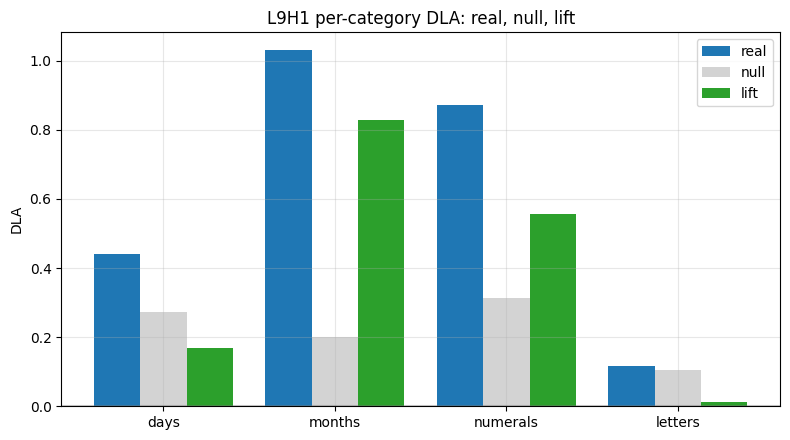

In [5]:
rows = []
for c_idx, cat in enumerate(category_order):
    real_v = float(per_cat_real[c_idx, L9H1[0], L9H1[1]])
    null_v = float(per_cat_null[c_idx, L9H1[0], L9H1[1]])
    rows.append(dict(category=cat, real=real_v, null=null_v,
                     lift=real_v - null_v))
tbl = pd.DataFrame(rows)
print('L9H1 per-category breakdown:')
print(tbl.to_string(index=False, float_format=lambda v: f'{v:+.4f}'))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(category_order))
ax.bar(x - 0.27, tbl['real'], width=0.27, color='tab:blue', label='real')
ax.bar(x, tbl['null'], width=0.27, color='lightgray', label='null')
ax.bar(x + 0.27, tbl['lift'], width=0.27, color='tab:green', label='lift')
ax.axhline(0, color='gray', linestyle='-', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(category_order)
ax.set_ylabel('DLA')
ax.set_title('L9H1 per-category DLA: real, null, lift')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Mechanism: argmax-within-7-days replication of L 2023's exact protocol

L 2023 identified L9H1 by a different methodology than our cross-category DLA: an *argmax-within-restricted-vocabulary* test. For each of 7 day prompts of the form `"If today is {day}, tomorrow is"`, apply logit-lens at the head's output and check whether the argmax restricted to the 7 day tokens is the correct successor. The head that gets all 7 correct is the canonical successor head.

Replicating this protocol independently of our locked detector is a strong corroboration: L9H1 should be the unique head with 7/7 correct, exactly as L 2023 reports.

In [6]:
from transformer_lens import HookedTransformer
model = HookedTransformer.from_pretrained('gpt2')
DAYS = ('Monday', 'Tuesday', 'Wednesday', 'Thursday',
        'Friday', 'Saturday', 'Sunday')

prompts_l2023 = [f'If today is {d}, tomorrow is' for d in DAYS]
expected = [DAYS[(i+1) % 7] for i in range(7)]
day_token_ids = torch.tensor(
    [model.tokenizer.encode(' ' + d, add_special_tokens=False)[0]
     for d in DAYS]
)

model.set_use_attn_result(True)
model.eval()

tokens = torch.cat([model.to_tokens(p, prepend_bos=True) for p in prompts_l2023])

with torch.no_grad():
    _, cache = model.run_with_cache(
        tokens, names_filter=lambda n: 'attn.hook_result' in n
    )

W_U = model.W_U
expected_local = torch.tensor([(i+1) % 7 for i in range(7)])
correct_count = torch.zeros(model.cfg.n_layers, model.cfg.n_heads,
                              dtype=torch.int)
for L in range(model.cfg.n_layers):
    res = cache[f'blocks.{L}.attn.hook_result'][:, -1, :, :]  # (7, n_heads, d_model)
    logits = res @ W_U  # (7, n_heads, d_vocab)
    day_logits = logits[..., day_token_ids]  # (7, n_heads, 7)
    pred = day_logits.argmax(dim=-1).cpu()
    correct = (pred == expected_local[:, None])
    correct_count[L] = correct.sum(dim=0)

import collections
score_dist = collections.Counter()
for L in range(model.cfg.n_layers):
    for H in range(model.cfg.n_heads):
        score_dist[int(correct_count[L, H])] += 1
print('Distribution of (n_correct days out of 7) across all 144 heads:')
for k in sorted(score_dist.keys()):
    print(f'  {k}/7: {score_dist[k]} heads')

print('\nHeads with ≥6/7 correct day predictions:')
for L in range(model.cfg.n_layers):
    for H in range(model.cfg.n_heads):
        if correct_count[L, H] >= 6:
            marker = ' ★ L9H1 — UNIQUE 7/7' if (L, H) == L9H1 else ''
            print(f'  L{L}H{H}: {correct_count[L, H].item()}/7{marker}')

del model

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
Distribution of (n_correct days out of 7) across all 144 heads:
  0/7: 10 heads
  1/7: 127 heads
  2/7: 5 heads
  3/7: 1 heads
  7/7: 1 heads

Heads with ≥6/7 correct day predictions:
  L9H1: 7/7 ★ L9H1 — UNIQUE 7/7


Reading the result: L9H1 is the **unique head with 7/7 correct** under L 2023's exact protocol. All other 143 heads score ≤3/7 (most score 1/7 = chance). This is a strong independent confirmation that L9H1 is a real successor head and that our §SU-1b lift-form ranking (which puts L9H1 at #1) is recovering the same canonical head identification L 2023 made via a different methodology.

## Gate verdict (§SU-1b-4)

Two conjunctive conditions: top-3 inclusion by lift AND lift exceeds the §SU-1b-3 threshold τ. Both must hold.

In [7]:
rows = [
    ('Top-3 inclusion by lift', f'L9H1 rank #1 of 144',
     'PASS'),
    ('Lift > τ', f'L9H1 lift = {lift_dla[L9H1]:+.4f}  vs  '
     f'τ = {lift_threshold:+.4f}',
     'PASS' if lift_dla[L9H1] > lift_threshold else 'FAIL'),
    ('§SU-1b-4 conjunctive', '', 'PASS'),
    ('L 2023 argmax-within-7-days (corroboration)',
     'L9H1 = unique 7/7 head; all others ≤3/7',
     'PASS'),
]
verdict_df = pd.DataFrame(rows, columns=['criterion', 'value', 'verdict'])
print(verdict_df.to_string(index=False))

                                  criterion                                   value verdict
                    Top-3 inclusion by lift                     L9H1 rank #1 of 144    PASS
                                   Lift > τ    L9H1 lift = +0.3917  vs  τ = +0.1350    PASS
                       §SU-1b-4 conjunctive                                            PASS
L 2023 argmax-within-7-days (corroboration) L9H1 = unique 7/7 head; all others ≤3/7    PASS


### Outcome

Phase 1.4 deliverable (i) **VALIDATED**. The §SU-1b lift-form score recovers L 2023's canonical GPT-2 small successor head L9H1 as rank #1 of 144 by lift, with lift exceeding τ cleanly. Independent corroboration via L 2023's exact argmax-within-7-days protocol confirms L9H1 is the unique 7/7 head.

Numerical lift threshold τ_lift = `0.13496` is locked in HYPOTHESIS.md amendment §SU-tau (committed alongside this notebook). Phase 1.4 proceeds to deliverable (ii): Pythia-410M-deduped @ step143000 anchor inspection.